## THIS NOTEBOOK DOES SHAP OF THE MODEL (XGBOOST)

In [2]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [5]:
xgb = joblib.load('../outputs/models/best_model.pkl')
X_val = pd.read_csv('../data/processed/X_val.csv')
y_val = pd.read_csv('../data/processed/y_val.csv')
explainer = shap.TreeExplainer(xgb)
shap_values = explainer(X_val)

The `shap_values` now contains the SHAP value for each feature

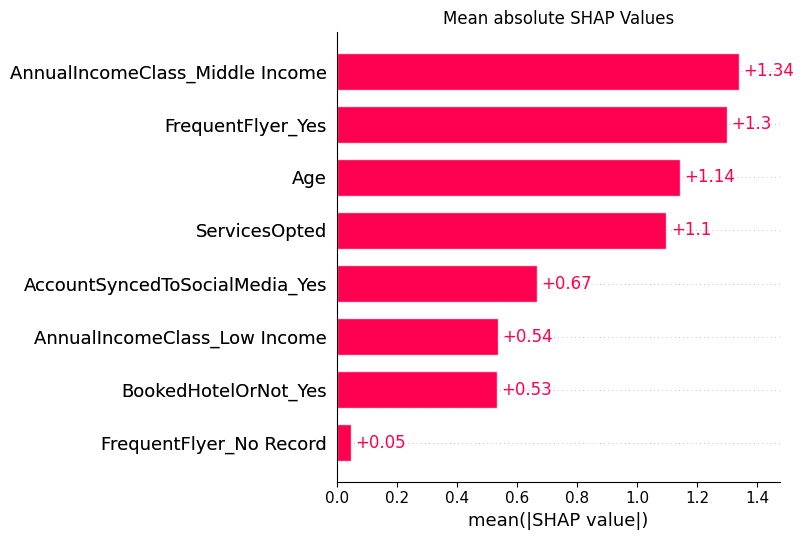

In [8]:
plt.figure()
shap.plots.bar(shap_values, show=False)
plt.title('Mean absolute SHAP Values')
plt.tight_layout()
plt.savefig('../outputs/figures/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

### Barplot Observation
This barplot showed how much each feature is contributing towards the prediction made by the model, with `AnnualIncomeClass_MiddleIncome` being the highest and `No Record` being the lowest.

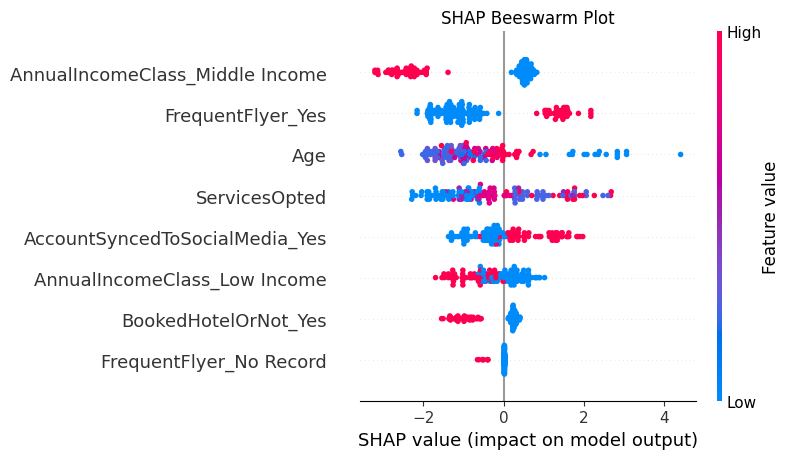

In [9]:
plt.figure()
shap.plots.beeswarm(shap_values, show=False)
plt.title('SHAP Beeswarm Plot')
plt.tight_layout()
plt.savefig('../outputs/figures/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

### Beeswarm plot Observation
This Beeswarm plot shows the distribution and affect of the features on churn or no churn likewise<br>
**Red** means yes and **Blue** means no in terms of feature<br>
As we can see, for **AnnualIncomeClass_MiddleIncome**, red`[middle_income_class]` pushes away from CHURN and has proper and clear distinction with blue, making it the most High Signal datapoint<br>
Similarly, **ServicesOpted** is all spread out, making the analysis slight confusing as is with other features which rank lower in contribution to prediction

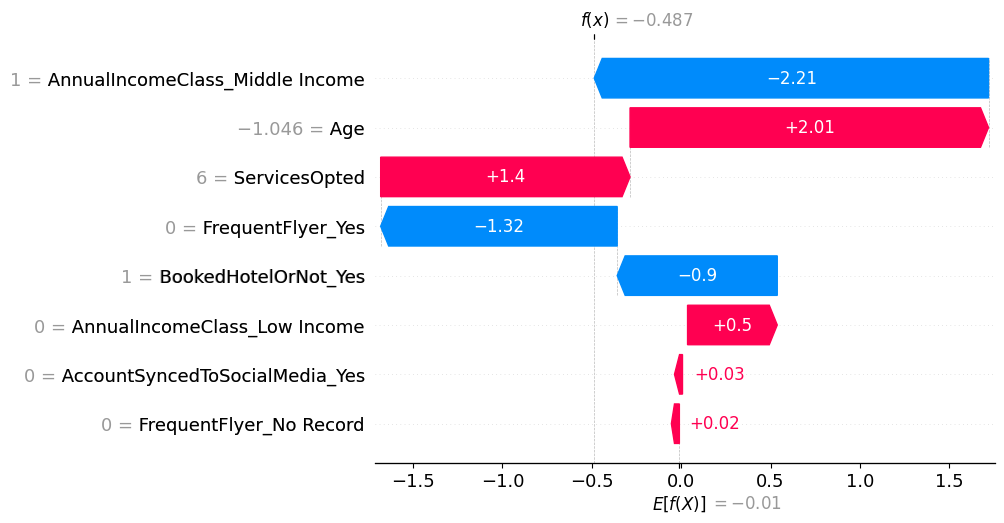

In [21]:
results_val = X_val.copy()
results_val['Actual'] = y_val.values
results_val['Predicted'] = xgb.predict(X_val)
results_val['Probability'] = xgb.predict_proba(X_val)[:, 1]

missed_churners = results_val[(results_val['Actual'] == 1) & (results_val['Predicted'] == 0)]
idx = missed_churners.index[0]

fig, ax = plt.subplots()
shap.plots.waterfall(shap_values[X_val.index.get_loc(idx)], show=False)
plt.savefig('../outputs/figures/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

### Observation of Waterfall plot (Misclassified datapoint)
This model has two overlapping indicators. It shows that young infrequent flyers (age in minus for it was scaled) with middle income are not falling under the model's churn profile, thus, the model misclassified.<br> Thus adding more definitive features will help this model
